In [1]:
import numpy as np
import pandas as pd

z_values = [-5, -2, -1, 0, 1, 2, 5]
p_values = 1 / (1 + np.exp(-np.array(z_values)))

df_sigmoid = pd.DataFrame({
    "score_z": z_values,
    "probability": p_values
})

df_sigmoid

,score_z,probability
0,-5,0.006693
1,-2,0.119203
2,-1,0.268941
3,0,0.500000
4,1,0.731059
5,2,0.880797
6,5,0.993307


In [2]:
#Odds Table
probabilities = [0.1, 0.3, 0.5, 0.7, 0.9]

odds_table = pd.DataFrame({
    "probability": probabilities
})

odds_table["odds"] = odds_table["probability"] / (1 - odds_table["probability"])

odds_table

,probability,odds
0,0.1,0.111111
1,0.3,0.428571
2,0.5,1.000000
3,0.7,2.333333
4,0.9,9.000000


In [3]:
#A customer has a 60% probability of churn.
#What are the odds of churn?
p = 0.6
odds = p / (1-p)
print(f"Odds of churn: {odds}")

Odds of churn: 1.4999999999999998


In [4]:
#Define the log-odds(given in the model)
log_odds = 2

#convert log-odds to odds using the exponent function
odds = np.exp(log_odds)

#convert odds to probability
probability = odds / (1 + odds)

#display the result
print(f"Log-odds: {log_odds}")
print(f"Odds: {odds:.2f}")
print(f"Probability: {probability:.2%}")

Log-odds: 2
Odds: 7.39
Probability: 88.08%


### Case Study 1: Customer Churn Prediction


In [5]:
#Download the Dataset
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/logistic_regression/synthetic_churn_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

df.to_csv("../../data_analytics_with_python/data/regression/logistic_regression/synthetic_churn_data.csv", index=False)

Dataset shape: (1000, 6)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           1000 non-null   int64  
 1   monthly_charges  1000 non-null   float64
 2   support_calls    1000 non-null   int64  
 3   contract_type    1000 non-null   int64  
 4   churn            1000 non-null   int64  
 5   education_level  1000 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 47.0 KB


In [7]:
#Target Variable Distribution
df['churn'].value_counts(normalize=True)

churn
0    0.633
1    0.367
Name: proportion, dtype: float64

In [8]:
#Churn Rate by Contract Type
churn_rate_by_contract = df.groupby('contract_type')['churn'].mean().reset_index()

import plotly.express as px

fig = px.bar(
    churn_rate_by_contract, 
    x='contract_type', 
    y='churn', 
    title='Churn Rate by Contract Type'
)
fig.update_layout(
    xaxis_title='Contract Type 0 = Prepaid, 1 = Postpaid',
    yaxis_title='Churn Rate',
    template='plotly_white'
)
fig.show()

In [9]:
#Churn Rate by Education Level
churn_rate_by_education = df.groupby('education_level')['churn'].mean().reset_index()
import plotly.express as px
fig = px.bar(churn_rate_by_education, x='education_level', y='churn', title='Churn Rate by Education Level')
fig.update_layout(
    xaxis_title='Education Level',
    yaxis_title='Churn Rate',
    template='plotly_white'
)   
fig.show()


In [10]:
#Data Preprocessing
X = df.drop(columns=["churn"])
y = df["churn"]

In [11]:
#Encoding Categorical Variables
education_order = ["High School", "Bachelor", "Master", "PhD"]

df["education_level"] = pd.Categorical(
    df["education_level"],
    categories=education_order,
    ordered=True
)

education_dummies = pd.get_dummies(
    df["education_level"],
    prefix="education",
    drop_first=True,
    dtype=int
)

education_dummies.head()

,education_Bachelor,education_Master,education_PhD
0,0,0,0
1,1,0,0
2,0,1,0
3,0,0,0
4,0,1,0


In [12]:
X_encoded = pd.concat([X.drop(columns=["education_level"]), education_dummies], axis=1)

X_encoded.head()

,tenure,monthly_charges,support_calls,contract_type,education_Bachelor,education_Master,education_PhD
0,29,46.867736,6,0,0,0,0
1,15,74.163421,6,0,1,0,0
2,8,83.347822,3,1,0,1,0
3,21,45.788769,2,0,0,0,0
4,19,33.935607,7,0,0,1,0


In [13]:
#Checking the final set of features
print("Final set of features:")
print(X_encoded.dtypes)

Final set of features:
tenure                  int64
monthly_charges       float64
support_calls           int64
contract_type           int64
education_Bachelor      int64
education_Master        int64
education_PhD           int64
dtype: object


In [14]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
#Output of train_test_split()
X_train, X_test, y_train, y_test

(     tenure  monthly_charges  support_calls  contract_type  \
 494      32        51.615610              6              0   
 687      26        52.433375              5              0   
 720      31        32.771348              2              0   
 381      33       100.172808              0              0   
 3        21        45.788769              2              0   
 ..      ...              ...            ...            ...   
 139      24        93.758230              8              1   
 565       3        57.325179              4              1   
 503      14       106.791829              9              0   
 759      20       106.201448              0              1   
 551      22        96.228513              0              0   
 
      education_Bachelor  education_Master  education_PhD  
 494                   1                 0              0  
 687                   0                 0              0  
 720                   1                 0              0  
 3

In [16]:
train_size = len(X_train)
test_size = len(X_test)

train_churn_rate = y_train.mean()
test_churn_rate = y_test.mean()

print("Training rows:", train_size)
print("Test rows:", test_size)
print("Training churn rate:", round(train_churn_rate, 3))
print("Test churn rate:", round(test_churn_rate, 3))

Training rows: 800
Test rows: 200
Training churn rate: 0.368
Test churn rate: 0.365


In [17]:
from sklearn.linear_model import LogisticRegression


In [18]:
#Training the Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
#Predicting Probabilities on the Test Set
probs = model.predict_proba(X_test)
probs[:5]

array([[0.9831887 , 0.0168113 ],
       [0.58272532, 0.41727468],
       [0.52510574, 0.47489426],
       [0.38401282, 0.61598718],
       [0.67937106, 0.32062894]])

In [20]:
probs = probs[:, 1]
probs[:5]

array([0.0168113 , 0.41727468, 0.47489426, 0.61598718, 0.32062894])

In [21]:
#Converting the Probabilities into Binary Predictions
threshold = 0.5
preds = (probs >= threshold).astype(int)
preds[:5]

array([0, 0, 0, 1, 0])

In [22]:
#Previewing the Predictions
prediction_results = X_test.copy()

prediction_results["actual_churn"] = y_test.values
prediction_results["predicted_probability"] = probs
prediction_results["predicted_churn"] = preds

prediction_results.head()

,tenure,monthly_charges,support_calls,contract_type,education_Bachelor,education_Master,education_PhD,actual_churn,predicted_probability,predicted_churn
361,34,55.062693,2,1,0,0,0,0,0.016811,0
5,23,103.493024,4,0,0,0,1,0,0.417275,0
692,25,75.778342,5,0,0,1,0,1,0.474894,0
708,6,112.717782,5,1,0,1,0,0,0.615987,1
841,26,67.601813,7,1,0,0,1,0,0.320629,0


In [23]:
#Coefficient Interpretation with Exponentiated Betas
coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "beta": model.coef_[0],
    "exp_beta": np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values("exp_beta", ascending=False)

coef_df

,feature,beta,exp_beta
2,support_calls,0.569345,1.767109
4,education_Bachelor,0.122861,1.130727
5,education_Master,0.112282,1.118828
1,monthly_charges,0.020345,1.020553
0,tenure,-0.055286,0.946214
6,education_PhD,-0.226251,0.797518
3,contract_type,-1.228898,0.292615


In [24]:
#Confusion Matrix
cm = confusion_matrix(y_test, preds)

tn, fp, fn, tp = cm.ravel()

cm

array([[103,  24],
       [ 23,  50]])

In [25]:
#Classification Metrics
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))

Accuracy: 0.765
Precision: 0.676
Recall: 0.685


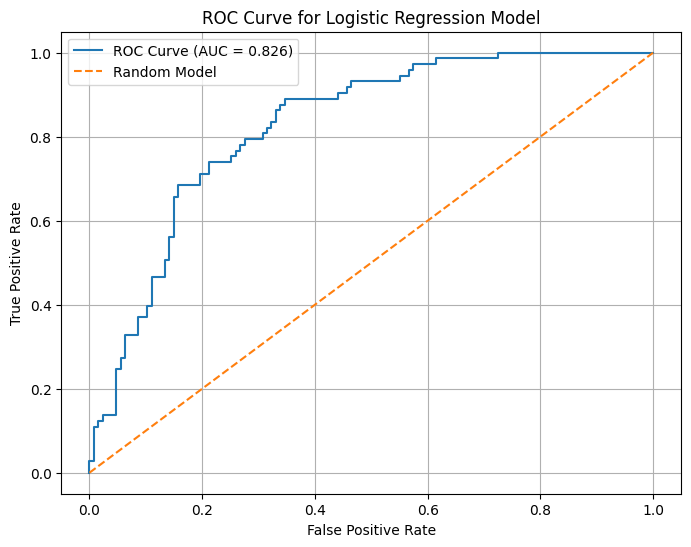

In [26]:
#ROC Curve Code
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
#Threshold Table from ROC Curve
roc_threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "false_positive_rate": fpr,
    "true_positive_rate": tpr
})

roc_threshold_table.head(10)

,threshold,false_positive_rate,true_positive_rate
0,inf,0.000000,0.000000
1,0.942003,0.000000,0.013699
2,0.918465,0.000000,0.027397
3,0.914074,0.007874,0.027397
4,0.872714,0.007874,0.109589
5,0.865494,0.015748,0.109589
6,0.864792,0.015748,0.123288
7,0.863049,0.023622,0.123288
8,0.856349,0.023622,0.136986
9,0.836169,0.047244,0.136986


In [28]:
#Revenue Matrix
retention_cost = 10
retention_benefit = 50

revenue_from_saved_customers = tp * (retention_benefit - retention_cost)
cost_from_unnecessary_contacts = fp * retention_cost

net_profit = revenue_from_saved_customers - cost_from_unnecessary_contacts

print("Revenue from saved customers:", revenue_from_saved_customers)
print("Cost from unnecessary contacts:", cost_from_unnecessary_contacts)
print("Net profit:", net_profit)

Revenue from saved customers: 2000
Cost from unnecessary contacts: 240
Net profit: 1760


### Homework: Customer Churn Prediction


In [145]:
#Import packages and load dataset
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/logistic_regression/Telco_Customer_Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [146]:
#Observing the Dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [147]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [148]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Exploratory Data Analysis


In [149]:
#Target Variable Distribution
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [150]:
df['Churn'].value_counts(normalize=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [151]:
df[['Churn', 'Contract']].value_counts(normalize=True)


Churn  Contract      
No     Month-to-month    0.315207
Yes    Month-to-month    0.234985
No     Two year          0.233849
       One year          0.185574
Yes    One year          0.023570
       Two year          0.006815
Name: proportion, dtype: float64

In [152]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [153]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [154]:
df = df.dropna(subset=["TotalCharges"])

In [155]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [156]:
df["Churn"].unique()

array([0, 1])

In [157]:
churn_rate = df.groupby("Contract")["Churn"].mean().reset_index()

In [158]:
churn_rate = df.groupby("Contract")["Churn"].mean().reset_index()
import plotly.express as px
fig = px.bar(
    churn_rate, 
    x='Contract', 
    y='Churn', 
    title='Churn Rate by Contract Type'
    )

fig.update_layout(
    xaxis_title='Contract Type',
    yaxis_title='Churn Rate',
    template='plotly_white'
)   
fig.show()

In [159]:
df.drop(columns=["customerID"], inplace=True)

In [160]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].map({"No": 0, "Yes": 1, "Female": 0, "Male": 1})

In [161]:
multi_cols = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [162]:
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
InternetService_Fiber optic              0
InternetService_No                       0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProte

In [169]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [163]:
df = pd.get_dummies(df, drop_first=True)

In [170]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [165]:
df["Churn"].isnull().sum()

np.int64(0)

In [171]:
df["Churn"].unique()

array([0, 1])

In [174]:
df = df.dropna(subset=["Churn"])

In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [176]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\Acer\miniconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [177]:
y_pred = model.predict(X_test)

In [178]:
y_prob = model.predict_proba(X_test)[:, 1]

In [179]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[917 116]
 [161 213]]


In [180]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8031272210376688
Precision: 0.6474164133738601
Recall: 0.56951871657754
F1: 0.6059743954480796


In [181]:
tp = cm[1,1]
fp = cm[0,1]
fn = cm[1,0]

print("True churn detected:", tp)
print("Missed churn:", fn)

True churn detected: 213
Missed churn: 161


In [182]:
import numpy as np
import pandas as pd

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_[0],
    "impact": np.exp(model.coef_[0])
})

coef_df.sort_values("impact", ascending=False)

,feature,coef,impact
14,InternetService_Fiber optic,0.676421,1.966826
12,PaymentMethod_Electronic check,0.388116,1.474200
6,PaperlessBilling,0.296901,1.345683
17,MultipleLines_Yes,0.276042,1.317904
16,MultipleLines_No phone service,0.250151,1.284219
27,StreamingTV_Yes,0.200867,1.222463
1,SeniorCitizen,0.195712,1.216177
29,StreamingMovies_Yes,0.172749,1.188567
13,PaymentMethod_Mailed check,0.076783,1.079807
11,PaymentMethod_Credit card (automatic),0.041531,1.042405
